=== ЗАВДАННЯ 1: Основи SciPy ===

--- Розподіл Бернуллі ---


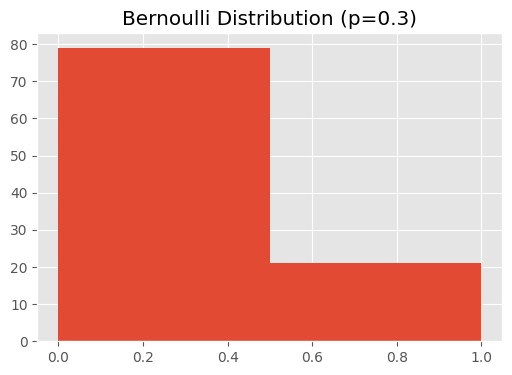


--- Рівномірний розподіл ---


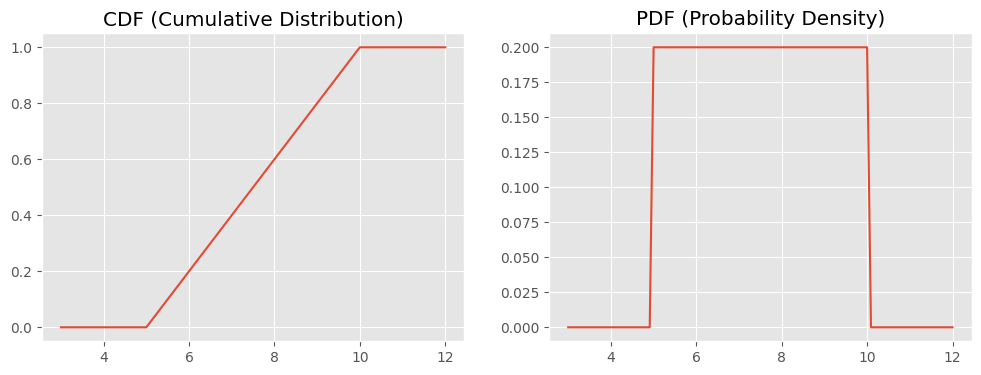


--- Нормальний розподіл ---


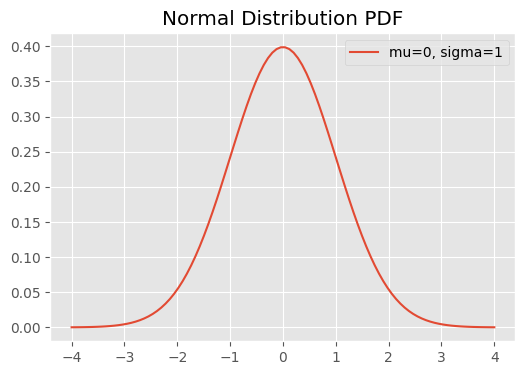

Normal Dist Stats -> Mean: 0.0, Variance: 1.0, Skew: 0.0


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.style.use('ggplot')

print("=== ЗАВДАННЯ 1: Основи SciPy ===")

# 1. Розподіл Бернуллі (Дискретний) [cite: 618-624]
print("\n--- Розподіл Бернуллі ---")
rv_bernoulli = stats.bernoulli(p=0.3) # p - ймовірність успіху
sample_bern = rv_bernoulli.rvs(size=100)

plt.figure(figsize=(6,4))
plt.hist(sample_bern, bins=2)
plt.title('Bernoulli Distribution (p=0.3)')
plt.show()

# 2. Рівномірний розподіл (Неперервний) [cite: 632-661]
print("\n--- Рівномірний розподіл ---")
a = 5
b = 10
# loc = початок, scale = довжина відрізка (b-a)
rv_uniform = stats.uniform(loc=a, scale=b-a) 

x = np.linspace(a - 2, b + 2, 100)
pdf_uni = rv_uniform.pdf(x) # Густина ймовірності
cdf_uni = rv_uniform.cdf(x) # Функція розподілу

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, cdf_uni)
ax[0].set_title('CDF (Cumulative Distribution)')
ax[1].plot(x, pdf_uni)
ax[1].set_title('PDF (Probability Density)')
plt.show()

# 3. Нормальний розподіл [cite: 662-696]
print("\n--- Нормальний розподіл ---")
mu = 0      # Середнє
sigma = 1   # Стандартне відхилення
rv_norm = stats.norm(loc=mu, scale=sigma)

x_norm = np.linspace(-4, 4, 100)
pdf_norm = rv_norm.pdf(x_norm)

plt.figure(figsize=(6,4))
plt.plot(x_norm, pdf_norm, label='mu=0, sigma=1')
plt.title('Normal Distribution PDF')
plt.legend()
plt.show()

# Статистики розподілу (Mean, Variance, Skew) [cite: 692-696]
mean_val, var_val, skew_val = rv_norm.stats(moments='mvs')
print(f"Normal Dist Stats -> Mean: {mean_val}, Variance: {var_val}, Skew: {skew_val}")

=== ЗАВДАННЯ 2: Довірчий інтервал (Video Game Sales) ===
Датасет успішно завантажено.


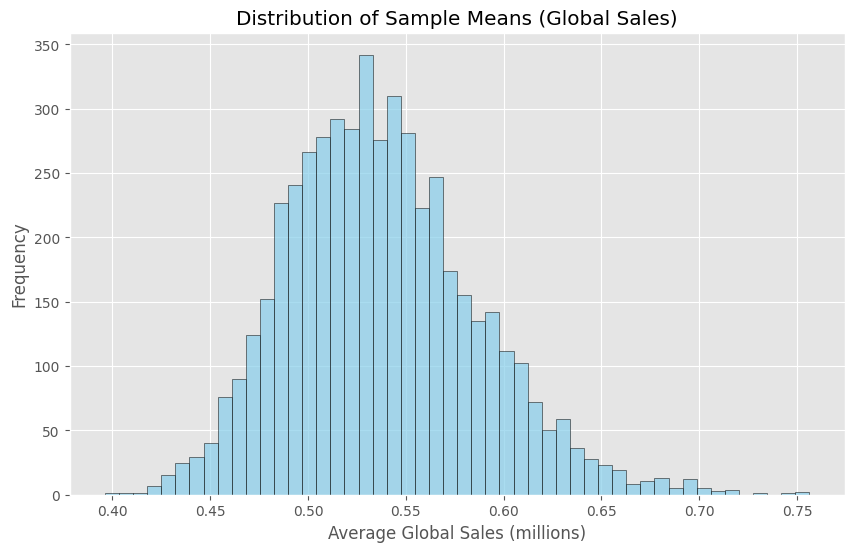

Фактичне середнє по датасету: 0.5374 млн.
95% Довірчий інтервал (Bootstrap): (0.4549, 0.6436)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Налаштування стилю
plt.style.use('ggplot')
%matplotlib inline

print("=== ЗАВДАННЯ 2: Довірчий інтервал (Video Game Sales) ===")

# 1. Завантаження даних
try:
    df = pd.read_csv('vgsales.csv')
    print("Датасет успішно завантажено.")
except FileNotFoundError:
    print("Файл не знайдено. Будь ласка, завантажте vgsales.csv.")
    # Для демонстрації, якщо файлу немає (імітація даних)
    df = pd.DataFrame({
        'Global_Sales': np.random.exponential(0.5, 1000),
        'NA_Sales': np.random.exponential(0.3, 1000),
        'EU_Sales': np.random.exponential(0.2, 1000),
        'Genre': np.random.choice(['Action', 'Sports'], 1000)
    })

# Працюємо з колонкою 'Global_Sales' (Глобальні продажі в млн копій)
data = df['Global_Sales'].dropna() # Видаляємо пропуски

# 2. Функція генерації вибіркових середніх (згідно з методичкою) [cite: 775-779]
def generate_distribution_sample(data, sample_size, dist_size):
    sample_means = []
    for i in range(dist_size):
        # random.choice робить вибірку з поверненням
        sample = np.random.choice(a=data, size=sample_size)
        sample_means.append(np.mean(sample))
    return sample_means

# 3. Генерація розподілу [cite: 780-785]
sample_size = 1000  # Розмір однієї вибірки
dist_size = 5000    # Кількість повторень (експериментів)

means_dist = generate_distribution_sample(data, sample_size, dist_size)

# 4. Візуалізація (Гістограма розподілу середніх) [cite: 786-789]
plt.figure(figsize=(10, 6))
plt.hist(means_dist, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sample Means (Global Sales)')
plt.xlabel('Average Global Sales (millions)')
plt.ylabel('Frequency')
plt.show()

# 5. Обчислення довірчого інтервалу (95%) [cite: 793-796]
# Використовуємо 2.5 та 97.5 перцентилі
lb = np.percentile(means_dist, 2.5)
ub = np.percentile(means_dist, 97.5)

print(f"Фактичне середнє по датасету: {data.mean():.4f} млн.")
print(f"95% Довірчий інтервал (Bootstrap): ({lb:.4f}, {ub:.4f})")

In [3]:
print("\n=== ЗАВДАННЯ 3: Перевірка гіпотез (T-test) ===")

# --- ТЕСТ 1: Одновибірковий (One-sample T-test) [cite: 818-822] ---
# H0: Середні глобальні продажі дорівнюють 0.5 млн.
# H1: Середні глобальні продажі НЕ дорівнюють 0.5 млн.

expected_mean = 0.5
# Беремо випадкову вибірку, щоб симулювати реальний експеримент (як у методичці n=3000)
sample_global = df['Global_Sales'].dropna().sample(n=3000, random_state=42)

t_stat, p_val = stats.ttest_1samp(sample_global, expected_mean)

print(f"\n[1] One-sample Test (Mean = {expected_mean}?)")
print(f"Sample Mean: {sample_global.mean():.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("Висновок: Відхиляємо H0. Середнє статистично відрізняється від 0.5.")
else:
    print("Висновок: Приймаємо H0.")


# --- ТЕСТ 2: Незалежні вибірки (Independent T-test) [cite: 832-835] ---
# Порівнюємо два жанри: Action vs Sports
# H0: Середні продажі Action і Sports однакові.

action_sales = df[df['Genre'] == 'Action']['Global_Sales'].dropna().sample(n=1000, random_state=42)
sports_sales = df[df['Genre'] == 'Sports']['Global_Sales'].dropna().sample(n=1000, random_state=42)

t_stat_ind, p_val_ind = stats.ttest_ind(action_sales, sports_sales)

print(f"\n[2] Independent Test (Action vs Sports Sales)")
print(f"Mean Action: {action_sales.mean():.4f}, Mean Sports: {sports_sales.mean():.4f}")
print(f"P-value: {p_val_ind:.4e}")

if p_val_ind < 0.05:
    print("Висновок: Відхиляємо H0. Жанри мають різну успішність продажів.")
else:
    print("Висновок: Приймаємо H0. Різниці немає.")


# --- ТЕСТ 3: Парний тест (Paired/Related T-test) [cite: 839-842] ---
# Порівнюємо продажі в Північній Америці (NA) та Європі (EU) для ОДНИХ І ТИХ САМИХ ігор.
# Це парна вибірка, бо ми порівнюємо два ринки для одного продукту.

# Беремо вибірку ігор
sample_games = df[['NA_Sales', 'EU_Sales']].dropna().sample(n=1000, random_state=42)

t_stat_rel, p_val_rel = stats.ttest_rel(sample_games['NA_Sales'], sample_games['EU_Sales'])

print(f"\n[3] Paired Test (NA Sales vs EU Sales)")
print(f"Mean NA: {sample_games['NA_Sales'].mean():.4f}, Mean EU: {sample_games['EU_Sales'].mean():.4f}")
print(f"P-value: {p_val_rel:.4e}")

if p_val_rel < 0.05:
    print("Висновок: Відхиляємо H0. Ринок Північної Америки статистично відрізняється від Європейського.")
else:
    print("Висновок: Приймаємо H0. Ринки ідентичні.")


=== ЗАВДАННЯ 3: Перевірка гіпотез (T-test) ===

[1] One-sample Test (Mean = 0.5?)
Sample Mean: 0.5634
P-value: 9.5272e-02
Висновок: Приймаємо H0.

[2] Independent Test (Action vs Sports Sales)
Mean Action: 0.5649, Mean Sports: 0.5115
P-value: 2.7132e-01
Висновок: Приймаємо H0. Різниці немає.

[3] Paired Test (NA Sales vs EU Sales)
Mean NA: 0.2615, Mean EU: 0.1454
P-value: 6.9986e-19
Висновок: Відхиляємо H0. Ринок Північної Америки статистично відрізняється від Європейського.
